In [2]:
## install finrl library if not installed

import pkg_resources
import pip
installedPackages = {pkg.key for pkg in pkg_resources.working_set} # list of installed packages

required = {'pandas','numpy', 'matplotlib','tensorflow','scikit-learn','keras-tuner','shap'
            }
missing = required - installedPackages
if missing:

    !pip install pandas
    !pip install numpy
    !pip install matplotlib
    !pip install tensorflow
    !pip install scikit-learn
    !pip install -q -U keras-tuner
    !pip install shap

<ipython-input-2-794d42089eab>:3: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
/usr/local/lib/python3.10/dist-packages/_distutils_hack/__init__.py:31: UserWarning: Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.8 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir("drive/My Drive/Asset_Allocation")

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from pandas_datareader import data as pdr

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from dateutil.relativedelta import relativedelta
import tensorflow as tf
import keras
from keras import layers
import random
import keras_tuner as kt
import shutil
import shap
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [5]:
#pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)

In [6]:
train_df = pd.read_pickle('datasets/train_data_m1_month.pkl')
test_df = pd.read_pickle('datasets/test_data_m1_month.pkl')

In [7]:
test_df.Date.min(),test_df.Date.max(),train_df.Date.min(),train_df.Date.max()

(Timestamp('2022-01-01 00:00:00'),
 Timestamp('2024-11-01 00:00:00'),
 Timestamp('2010-01-01 00:00:00'),
 Timestamp('2021-12-01 00:00:00'))

In [8]:
train_df.head()

,Date,Ticker,close,high,low,open,volume,monthly_return,target,monthly_return_6_sma,...,wt2,supertrend_ub,supertrend_lb,vwma_3,gdp,unemployment rate,consumer price index,federal funds rate,interest rate,federal debt
4,2010-01-01,AAPL,5.786131,6.495012,5.731602,6.429938,15168994400,-0.088597,0.065396,0.010763,...,104.539884,7.558034,3.840699,6.044047,14764.610000,9.800000,217.488000,0.110000,0.05,1.277312e+07
5,2010-02-01,AAPL,6.164524,6.181093,5.749679,5.795472,10776080000,0.065396,0.148470,0.021690,...,92.697784,7.558034,3.887466,6.059565,14836.471000,9.833333,217.459667,0.140000,0.09,1.291601e+07
6,2010-03-01,AAPL,7.079769,7.154484,6.189526,6.198564,12154172800,0.148470,0.111022,0.042820,...,89.076892,7.558034,4.436671,6.268415,14908.332000,9.866667,217.431333,0.170000,0.13,1.305890e+07
7,2010-04-01,AAPL,7.865777,8.208316,7.011986,7.152376,12367129600,0.111022,-0.016125,0.058491,...,89.838659,7.558034,5.158634,6.881899,14980.193000,9.900000,217.403000,0.200000,0.17,1.320179e+07
8,2010-05-01,AAPL,7.738943,8.070336,6.002742,7.948624,18082654800,-0.016125,-0.020827,0.045715,...,94.397524,10.038551,5.158634,7.261938,15033.997667,9.733333,217.470333,0.193333,0.17,1.332174e+07


In [9]:
train_df.isna().sum().sum(),test_df.isna().sum().sum()

(0, 0)

In [10]:
# Set seeds for reproducibility
#tf.random.set_seed(42)
#np.random.seed(42)
#random.seed(42)
#tf.config.experimental.enable_op_determinism()
#random_tensor = tf.random.stateless_uniform(shape=[2, 3], seed=[42, 42])

#Set features
all_features = test_df.drop(columns = ['Date','target','Ticker']).columns.tolist()
data = pd.concat([train_df,test_df])
data.reset_index(drop=True, inplace=True)

In [15]:
unique_trade_date = test_df.Date.unique()
validation_size = 12*4 # Months
training_size = 7 # Years

def neural_model_builder(hp):
  #hp_l2 = hp.Float('l2', min_value=0.01, max_value=1, sampling='LOG')
  hp_l2 =  hp.Choice('l2', values=[0.01, 0.05, 0.1])
  model = keras.Sequential([
      layers.Input(shape=(95,)),
      layers.Dense(32, activation='relu'),
      layers.BatchNormalization(),
      layers.Dense(16, activation='relu'),
      layers.Dense(1,kernel_regularizer=tf.keras.regularizers.L2(
    l2=hp_l2
))
  ])
  hp_learning_rate = hp.Choice('learning_rate', values=[1e-3, 1e-2])
  lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    hp_learning_rate,
    decay_steps=100000,
    decay_rate=0.96,
    staircase=True
)
  optimizer = tf.keras.optimizers.Adam(lr_schedule)

  model.compile(loss = "mse",optimizer = optimizer)
  return model

def hyperparameter_serach_neural_network(XlearnT, ylearnT,XvalT, yvalT):
  tuner = kt.RandomSearch(neural_model_builder,
                      objective='val_loss',
                        max_trials=3,
                        executions_per_trial=1,
                        max_retries_per_trial=1,
                        overwrite=True,
                      directory='keras_hyperparameter_search',
                      project_name='return_prediction')


  early_stop = keras.callbacks.EarlyStopping(monitor = "val_loss",
                                              patience = 5)
  tuner.search(XlearnT, ylearnT, epochs=50, validation_data=(XvalT, yvalT), callbacks=[early_stop], verbose=0)
  return tuner

def rolling_window_training(unique_trade_date, data,validation_size, training_size):
  history_all = []
  val_loss = []
  val_r2 = []
  train_loss = []
  train_r2 = []
  test_preds = []
  test_loss = []
  test_r2 = []
  for i in unique_trade_date:
    print(i)
    test_date = i
    validation_date_start = test_date - relativedelta(months=validation_size)
    training_date_start = validation_date_start - relativedelta(years=training_size)
    #print(test_date,validation_date_start)

    #set train, validation, test sets
    train_df = data[(data.Date >=training_date_start) & (data.Date <validation_date_start)]
    val_df =  data[(data.Date >=validation_date_start) & (data.Date <test_date)]
    test_df = data[data.Date == test_date]

    XlearnT, ylearnT = train_df[all_features],train_df[['target']]
    XvalT, yvalT = val_df[all_features],val_df[['target']]

    # Parameters
    batch_size = 50
    epoch = 100
    early_stop = keras.callbacks.EarlyStopping(monitor = "val_loss",
                                              patience = 5)
    #Normalziation
    scaler = StandardScaler()
    XlearnT = scaler.fit_transform(XlearnT)
    XvalT = scaler.fit_transform(XvalT)

    # find the model on validation set
    tuner = hyperparameter_serach_neural_network(XlearnT, ylearnT,XvalT, yvalT)
     # Get the optimal hyperparameters
    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

    print(f"""
    The hyperparameter search is complete. The optimal learning rate
    is {best_hps.get('learning_rate')}. the optimal L2 regularization factor is {best_hps.get('l2')}
    """)
    # Build the model with the optimal hyperparameters
    best_model = tuner.hypermodel.build(best_hps)

    history = best_model.fit(XlearnT, ylearnT,
                    epochs = epoch,
                    batch_size = batch_size,
                    verbose = 0,
                    validation_data = (XvalT, yvalT),
                    callbacks = [early_stop])

    history_all.append(history)
    preds = best_model.predict(XlearnT)
    val_preds = best_model.predict(XvalT)

    val_loss.append(root_mean_squared_error(yvalT, val_preds))
    val_r2.append(r2_score(yvalT, val_preds))
    train_loss.append(root_mean_squared_error(ylearnT, preds))
    train_r2.append(r2_score(ylearnT, preds))

    #retrain the model with the all train data
    new_epochs = len(history.history['loss'])
    training_date_start = test_date - relativedelta(years=training_size)
    train_df = data[(data.Date >=training_date_start) & (data.Date <test_date)]

    XlearnT, ylearnT = train_df[all_features],train_df[['target']]
    test_X, test_y = test_df[all_features],test_df[['target']]

    scaler = StandardScaler()
    XlearnT = scaler.fit_transform(XlearnT)
    test_X = scaler.transform(test_X)

    #retrain in train+validation
    # Build the model with the optimal hyperparameters
    best_model = tuner.hypermodel.build(best_hps)

    history = best_model.fit(XlearnT, ylearnT,
                      epochs = new_epochs,
                      batch_size = batch_size,
                      verbose = 0)

    test_pred = best_model.predict(test_X)
    test_y['pred'] = test_pred
    test_preds.append(test_y['pred'])
    test_loss.append(root_mean_squared_error(test_y['target'], test_y['pred']))
    test_r2.append(r2_score(test_y['target'], test_y['pred']))

  return   history_all,val_r2, train_loss,val_loss, train_r2, test_preds, test_loss ,test_r2, best_model, XlearnT, XvalT

In [16]:
history_all,val_r2, train_loss,val_loss, train_r2, test_preds, test_loss ,test_r2, neural_model, XlearnT, XvalT = rolling_window_training(unique_trade_date, data,validation_size, training_size)
neural_model.summary()

2022-01-01 00:00:00

    The hyperparameter search is complete. The optimal learning rate 
    is 0.01. the optimal L2 regularization factor is 0.1
    
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
2022-02-01 00:00:00


<ipython-input-15-3878b5b0f379>:129: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_y['pred'] = test_pred



    The hyperparameter search is complete. The optimal learning rate 
    is 0.01. the optimal L2 regularization factor is 0.05
    
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
2022-03-01 00:00:00


<ipython-input-15-3878b5b0f379>:129: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_y['pred'] = test_pred



    The hyperparameter search is complete. The optimal learning rate 
    is 0.01. the optimal L2 regularization factor is 0.1
    
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
2022-04-01 00:00:00


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 32)                  │           3,072 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,108 (43.39 KB)

 Trainable params: 3,681 (14.38 KB)

 Non-trainable params: 64 (256.00 B)

 Optimizer params: 7,363 (28.77 KB)

Average Train Loss= 0.06
Average Validation Loss = 0.083
Test Loss = 0.085
Train R2 Min= -7.5% and Max= 8.4%
Validation R2 = -0.84% and Max= 1.5%
Test R2 = -7.0%


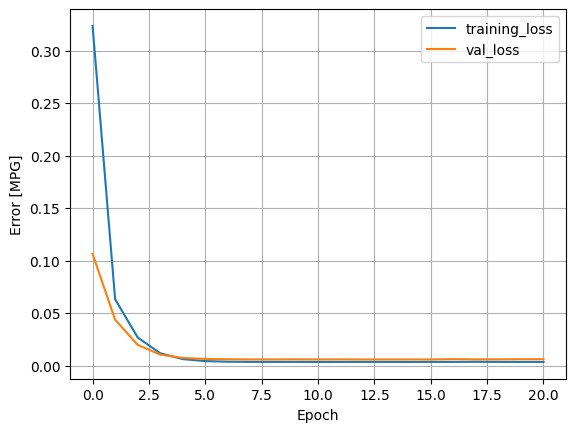

In [17]:
test_df.reset_index(drop=True, inplace=True)
test_df['expected_target'] = pd.concat(test_preds).reset_index(drop=True)
print('Average Train Loss= {:.2}'.format(np.mean(train_loss)))
print('Average Validation Loss = {:.2}'.format(np.mean(val_loss)))
print('Test Loss = {:.2}'.format(root_mean_squared_error(test_df['target'], test_df['expected_target'])))
print('Train R2 Min= {:.2}% and Max= {:.2}%'.format(np.min(train_r2)*100,np.max(train_r2)*100))
print('Validation R2 = {:.2}% and Max= {:.2}%'.format(np.mean(val_r2)*100,np.max(val_r2)*100))
print('Test R2 = {:.2}%'.format(r2_score(test_df['target'], test_df['expected_target'])*100))
def plot_loss(history):
  plt.plot(history.history['loss'], label='training_loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  #plt.ylim([0, 10])
  plt.xlabel('Epoch')
  plt.ylabel('Error [MPG]')
  plt.legend()
  plt.grid(True)
plot_loss(history_all[0])

PermutationExplainer explainer: 1441it [04:23,  5.47it/s]


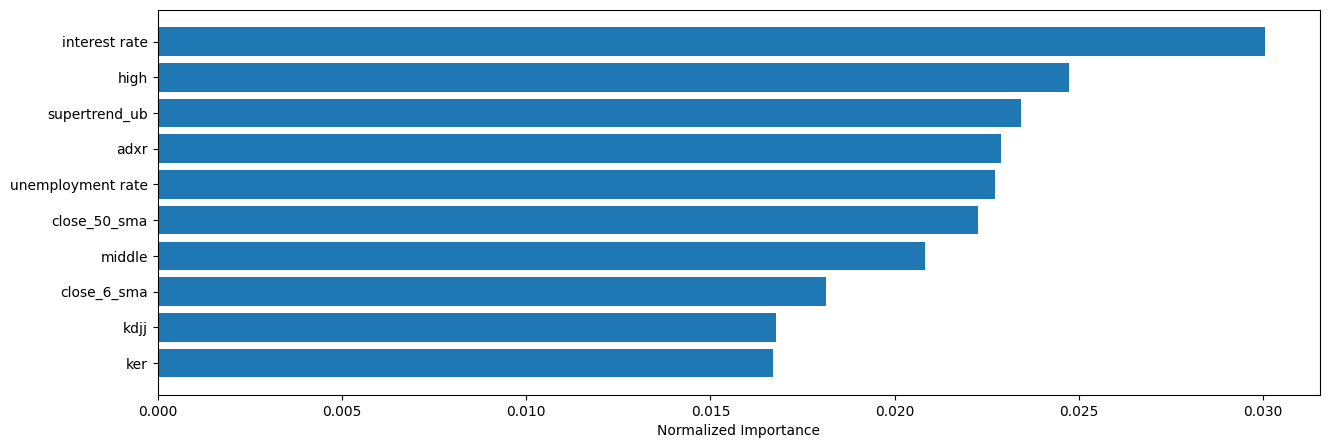

In [18]:
# Use SHAP to explain the model's predictions
explainer = shap.Explainer (neural_model, XlearnT)
shap_values = explainer.shap_values(XvalT)
#Normaliz shap values
mean_abs_shap_values = np.mean(np.abs(shap_values), axis=0)
# Normalize the feature importances to sum to 1
normalized_importances = mean_abs_shap_values / np.sum(mean_abs_shap_values)

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': normalized_importances
}).sort_values(by='Importance', ascending=False)

# Plot the top 10 normalized feature importances
top_features = importance_df.head(10)
plt.figure(figsize=(15, 5))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Normalized Importance')
#plt.title('Top 10 Normalized Feature Importances')
plt.gca().invert_yaxis()
plt.savefig('NN_feature_importance.png')
plt.show()

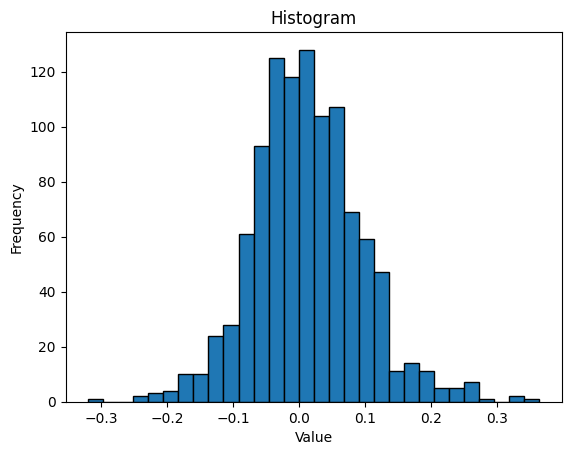

In [19]:
plt.hist(test_df.target, bins=30, edgecolor='black')
plt.title('Histogram')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()


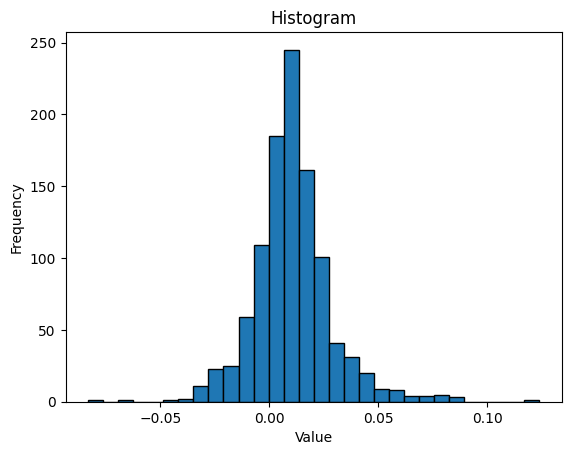

In [20]:
plt.hist(test_df.expected_target, bins=30, edgecolor='black')
plt.title('Histogram')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

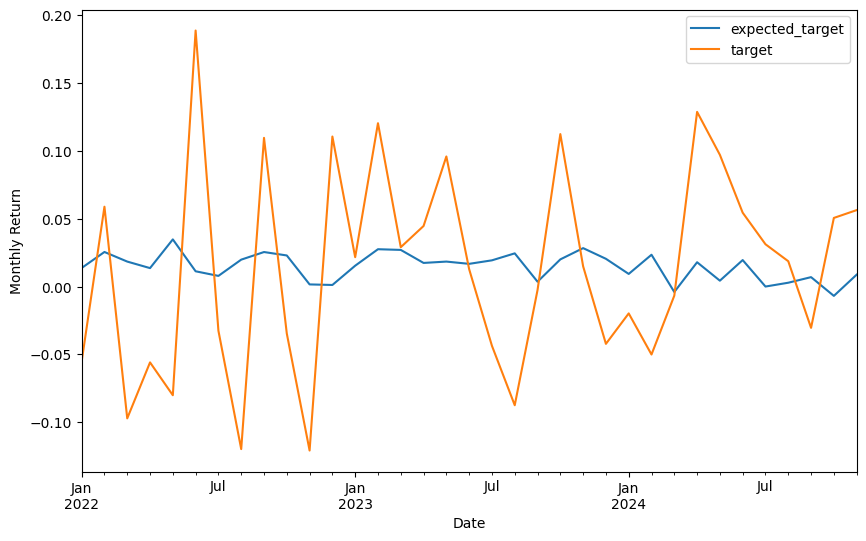

In [21]:
ax = test_df[test_df.Ticker == 'AAPL'].plot.line(y=["expected_target",'target'], x='Date', ylabel='Monthly Return',xlabel = 'Date', figsize=(10, 6))
fig = ax.get_figure()
fig.savefig('NN_returns.png')

In [22]:
train_df.to_pickle('datasets/train_data_m1_result.pkl')
test_df.to_pickle('datasets/test_data_m1_result.pkl')